## WEATHER DATA DASHBOARD - Complete Analysis

#### This notebook handles everything: loading, analysis, visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

#### 1. LOAD AND PREPROCESS DATA

In [5]:
file_path = "../data/weather_data.csv" 
df = pd.read_csv(file_path)

In [6]:
print("DATASET INFORMATION")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
display(df.head())

DATASET INFORMATION
Shape: (1000000, 6)

Columns:
Location                str
Date_Time               str
Temperature_C       float64
Humidity_pct        float64
Precipitation_mm    float64
Wind_Speed_kmh      float64
dtype: object

First 5 rows:


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


In [8]:
# Converting Date_Time to datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

In [9]:
# Getting the unique locations
locations = df['Location'].unique().tolist()
print(f"\nUnique Locations: {locations}")


Unique Locations: ['San Diego', 'Philadelphia', 'San Antonio', 'San Jose', 'New York', 'Houston', 'Dallas', 'Chicago', 'Los Angeles', 'Phoenix']


In [10]:
# Creating a separate dataframe for each location
location_data = {}
for loc in locations:
    location_data[loc] = df[df['Location'] == loc].copy()
    location_data[loc].set_index('Date_Time', inplace=True)
    location_data[loc].sort_index(inplace=True)

In [11]:
# Setting main dataframe index to Date_Time with Location as well
df.set_index('Date_Time', inplace=True)

In [13]:
# Defining weather columns
weather_cols = ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
display_names = {
    'Temperature_C': 'Temperature (°C)',
    'Humidity_pct': 'Humidity (%)',
    'Precipitation_mm': 'Precipitation (mm)',
    'Wind_Speed_kmh': 'Wind Speed (km/h)'
}

print(f"\nWeather Variables: {', '.join(weather_cols)}")


Weather Variables: Temperature_C, Humidity_pct, Precipitation_mm, Wind_Speed_kmh


In [14]:
# Checking for missing values
print(f"\nMissing values:\n{df[weather_cols].isnull().sum()}")


Missing values:
Temperature_C       0
Humidity_pct        0
Precipitation_mm    0
Wind_Speed_kmh      0
dtype: int64


In [15]:
# Interpolating missing values if any
for loc in locations:
    location_data[loc][weather_cols] = location_data[loc][weather_cols].interpolate(method='time')

print("\n✅ Data loaded and preprocessed successfully!")


✅ Data loaded and preprocessed successfully!


#### 2. DATA SUMMARY STATISTICS

In [16]:
# Overall statistics
print("\nOverall Statistics (All Locations):")
display(df[weather_cols].describe())


Overall Statistics (All Locations):


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


In [17]:
# Location-wise summary
print("\nLocation-wise Summary:")
location_summary = []

for loc in locations:
    data = location_data[loc]
    summary = {
        'Location': loc,
        'Records': len(data),
        'Date Range': f"{data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}",
        'Avg Temperature (°C)': data['Temperature_C'].mean(),
        'Avg Humidity (%)': data['Humidity_pct'].mean(),
        'Total Precipitation (mm)': data['Precipitation_mm'].sum(),
        'Avg Wind Speed (km/h)': data['Wind_Speed_kmh'].mean()
    }
    location_summary.append(summary)

location_df = pd.DataFrame(location_summary)
display(location_df)


Location-wise Summary:


,Location,Records,Date Range,Avg Temperature (°C),Avg Humidity (%),Total Precipitation (mm),Avg Wind Speed (km/h)
0,San Diego,99774,2024-01-01 to 2024-05-18,14.933539,60.072074,499527.824545,15.037633
1,Philadelphia,100122,2024-01-01 to 2024-05-18,15.035892,60.044902,501467.096065,14.990663
2,San Antonio,99962,2024-01-01 to 2024-05-18,15.027761,59.932798,500618.815548,14.956579
3,San Jose,99863,2024-01-01 to 2024-05-18,14.956108,59.986630,498056.565832,14.971369
4,New York,99972,2024-01-01 to 2024-05-18,15.013389,60.044688,499165.847509,14.989398
5,Houston,100076,2024-01-01 to 2024-05-18,14.942985,59.967598,500155.541871,14.989935
6,Dallas,99936,2024-01-01 to 2024-05-18,15.009097,59.959900,499430.926801,15.022001
7,Chicago,100164,2024-01-01 to 2024-05-18,15.009208,60.088798,501136.925500,14.999501
8,Los Angeles,99922,2024-01-01 to 2024-05-18,15.081063,60.072151,500058.770553,15.035120
9,Phoenix,100209,2024-01-01 to 2024-05-18,12.792479,60.048643,610020.811753,14.983904


In [18]:
# Summary per location statistics
for loc in locations:
    print(f"\nDetailed Statistics for {loc}:")
    display(location_data[loc][weather_cols].describe())


Detailed Statistics for San Diego:


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,99774.000000,99774.000000,99774.000000,99774.000000
mean,14.933539,60.072074,5.006593,15.037633
std,14.432428,17.287227,2.885056,8.686589
min,-9.999986,30.001341,0.000089,0.000614
25%,2.442428,45.122973,2.521052,7.504503
50%,14.839506,60.160830,5.013095,15.066118
75%,27.439124,74.970932,7.494823,22.600464
max,39.999692,89.998941,9.999716,29.999920



Detailed Statistics for Philadelphia:


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,100122.000000,100122.000000,100122.000000,100122.000000
mean,15.035892,60.044902,5.008561,14.990663
std,14.410762,17.269700,2.895058,8.647465
min,-9.999282,30.000009,0.000454,0.000272
25%,2.550614,45.062014,2.492420,7.510187
50%,15.084902,60.112821,5.028842,14.968510
75%,27.511431,74.995718,7.525349,22.471823
max,39.999642,89.999332,9.999944,29.999973



Detailed Statistics for San Antonio:


...

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,100164.000000,100164.000000,100164.000000,100164.000000
mean,15.009208,60.088798,5.003164,14.999501
std,14.444326,17.336360,2.886279,8.667839
min,-9.999959,30.001637,0.000118,0.000171
25%,2.486382,45.042424,2.503122,7.501627
50%,15.002933,60.109931,4.999396,14.969179
75%,27.498216,75.096476,7.503939,22.534902
max,39.998561,89.998857,9.999889,29.999889



Detailed Statistics for Los Angeles:


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,99922.000000,99922.000000,99922.000000,99922.000000
mean,15.081063,60.072151,5.004491,15.035120
std,14.476483,17.305097,2.886508,8.675607
min,-9.999913,30.000223,0.000153,0.000173
25%,2.519630,45.135447,2.505462,7.493099
50%,15.066194,60.005741,5.002282,15.022371
75%,27.611975,75.091823,7.507905,22.592377
max,39.999592,89.998014,9.999522,29.999757



Detailed Statistics for Phoenix:


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,100209.000000,100209.000000,100209.000000,100209.000000
mean,12.792479,60.048643,6.087485,14.983904
std,14.765594,17.329180,3.277201,8.666228
min,-19.969311,30.002950,0.000032,0.000090
25%,0.285965,44.958397,3.500441,7.471618
50%,12.758345,60.046024,6.087943,14.964395
75%,25.326254,75.131276,8.578512,22.521212
max,39.998889,89.999666,14.971583,29.999392


#### 3. TIME SERIES VISUALIZATIONS

In [19]:
def plot_time_series(location=None, columns=None, figsize=(15, 10)):
    """Plot time series for weather variables"""
    if location:
        data = location_data[location]
        title = f"Time Series - {location}"
    else:
        data = df
        title = "Time Series - All Locations"
    
    if columns is None:
        columns = weather_cols[:4]
    
    fig, axes = plt.subplots(len(columns), 1, figsize=figsize)
    if len(columns) == 1:
        axes = [axes]
    
    for i, col in enumerate(columns):
        # Resample if too many points
        if len(data) > 10000:
            plot_data = data[col].resample('D').mean()
        else:
            plot_data = data[col]
        
        axes[i].plot(plot_data.index, plot_data.values, linewidth=1.5)
        axes[i].set_title(f'{display_names.get(col, col)} Over Time', fontsize=12)
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel(display_names.get(col, col))
        axes[i].grid(True, alpha=0.3)
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


Plotting time series for all locations...


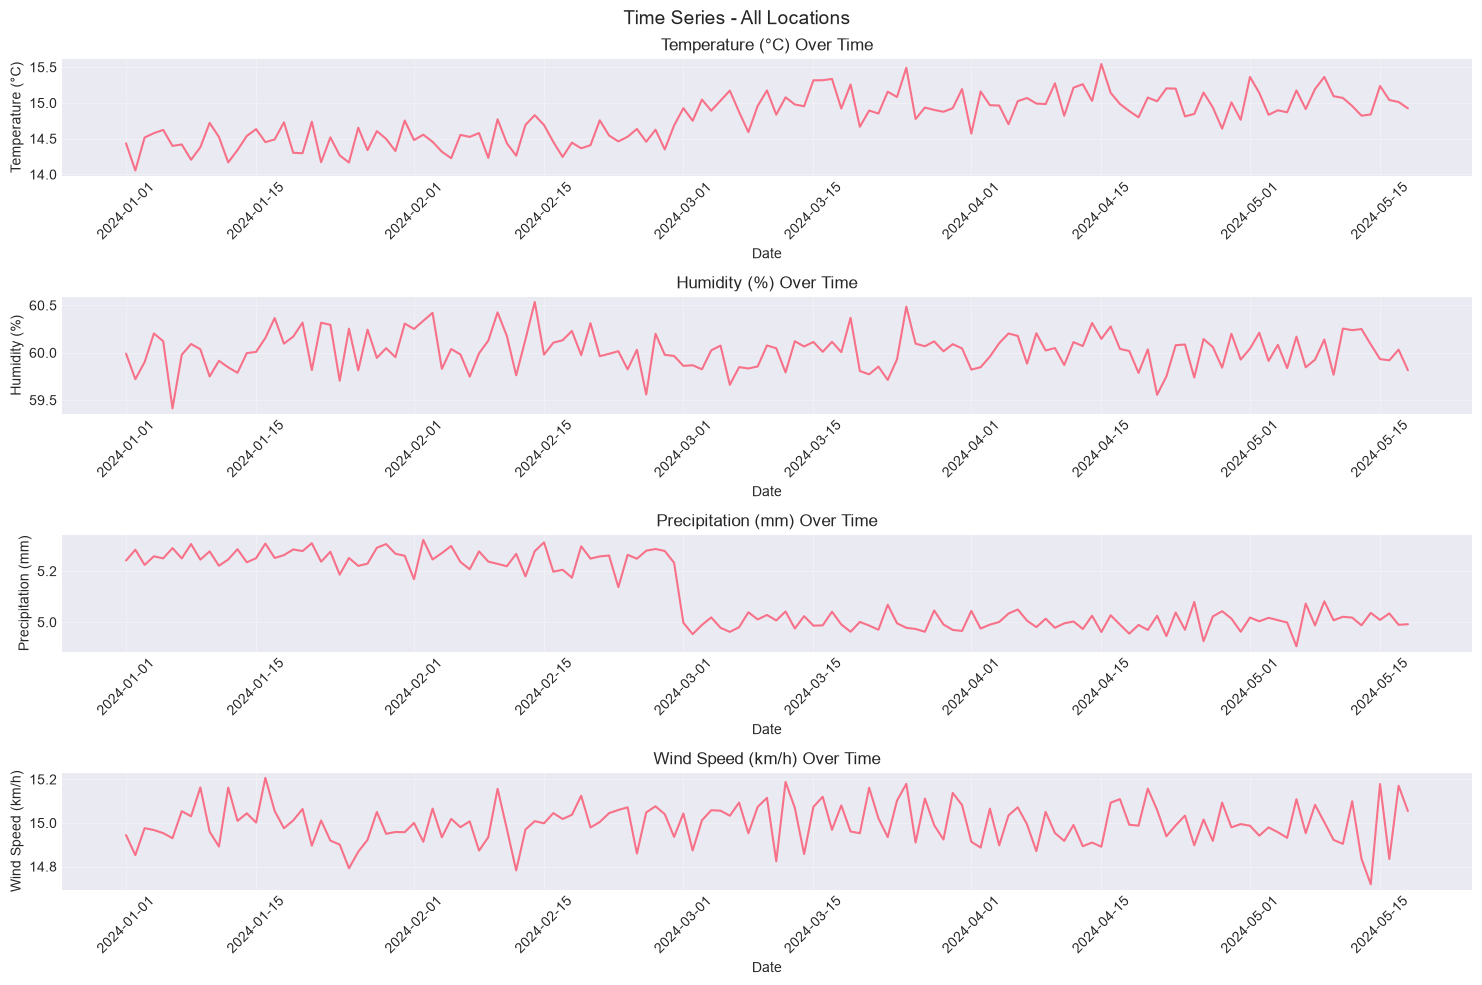

In [20]:
# Plotting time series for all locations combined
print("\nPlotting time series for all locations...")
plot_time_series()


Plotting time series for San Diego...


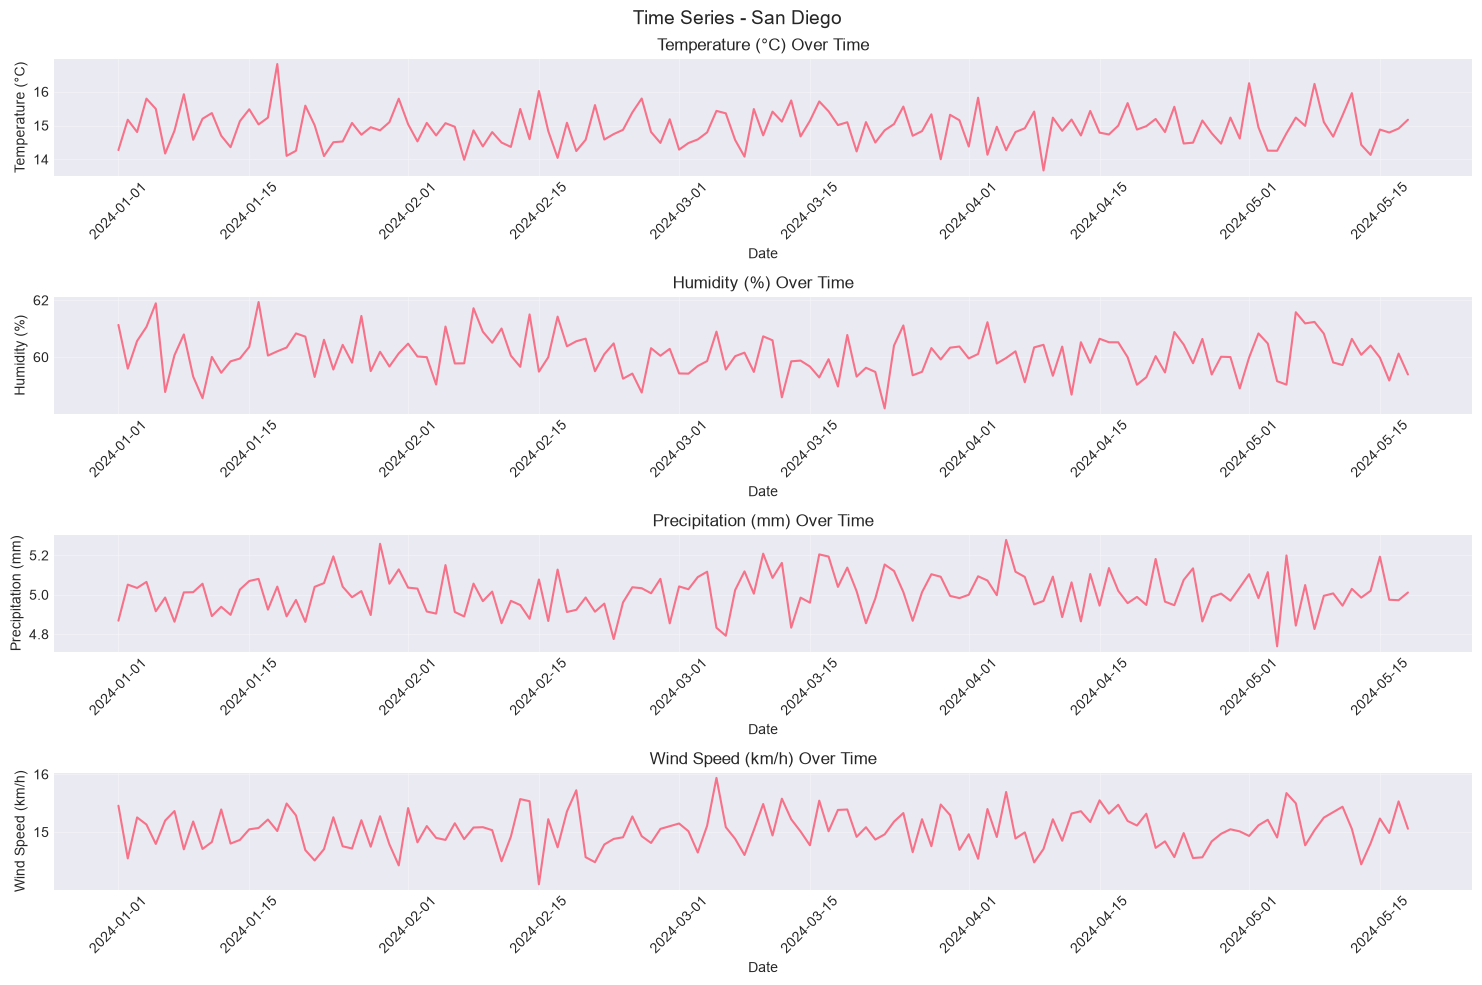


Plotting time series for Philadelphia...


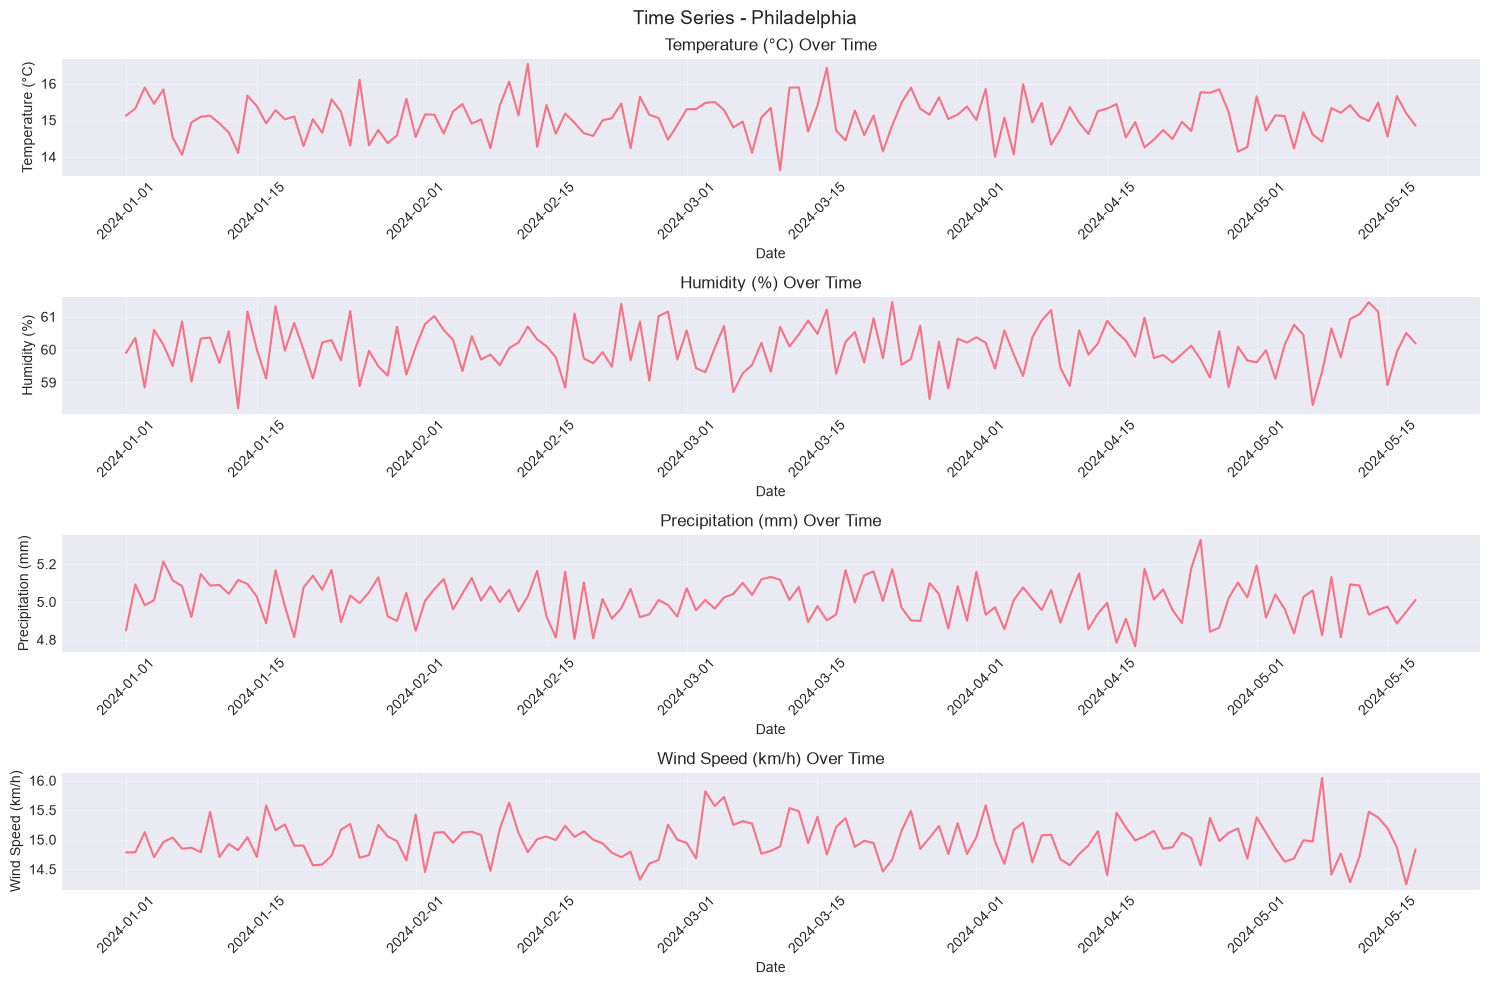


Plotting time series for San Antonio...


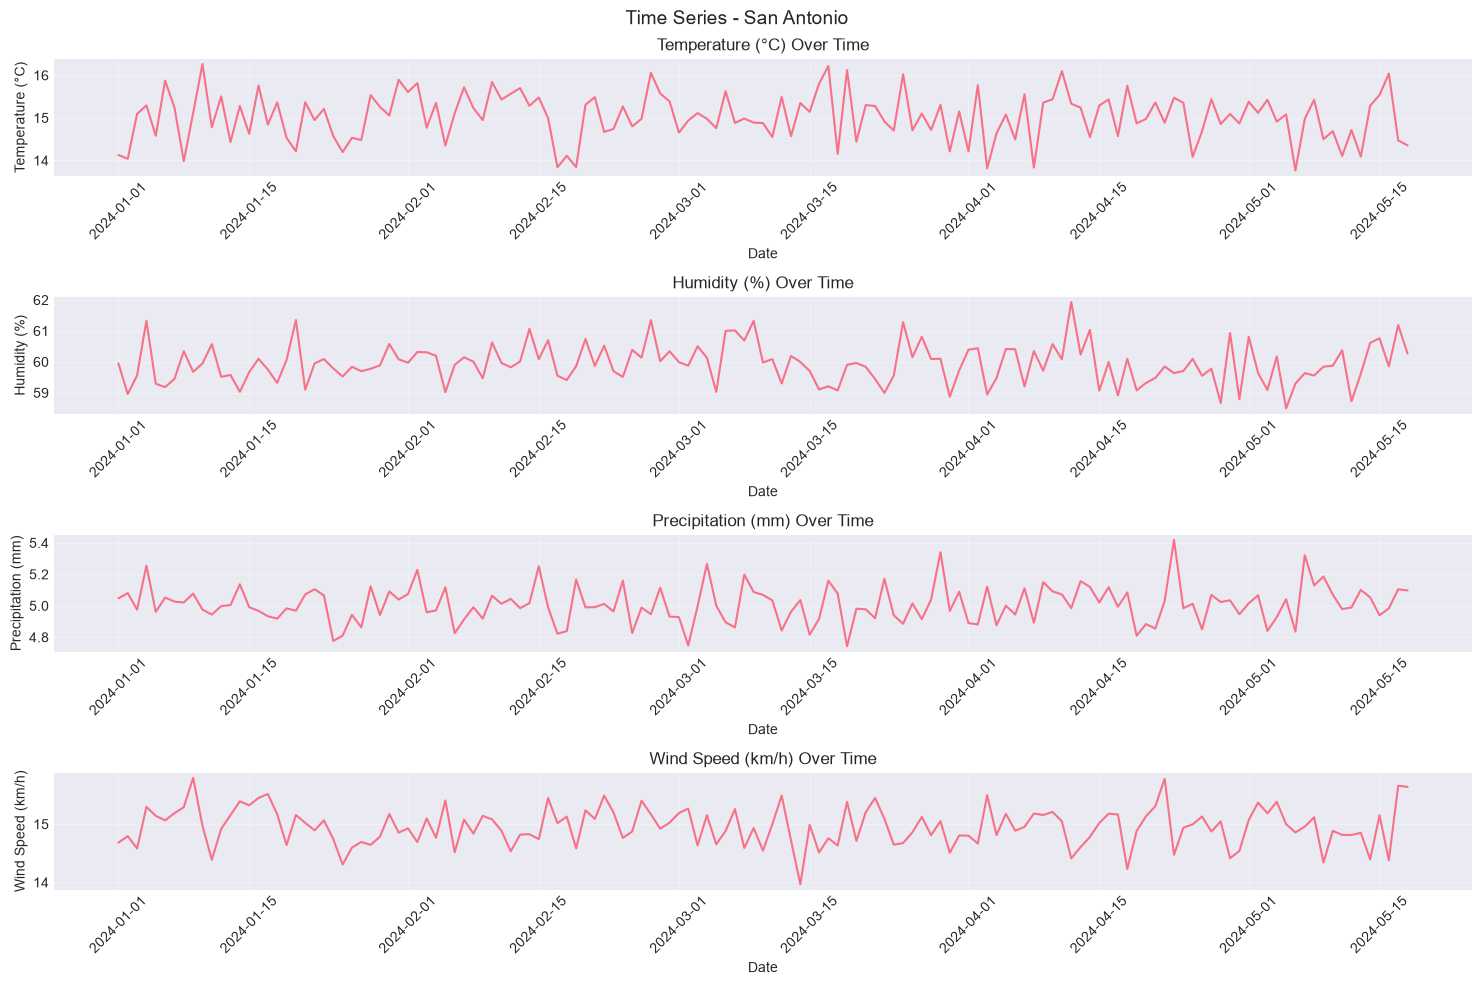


Plotting time series for San Jose...


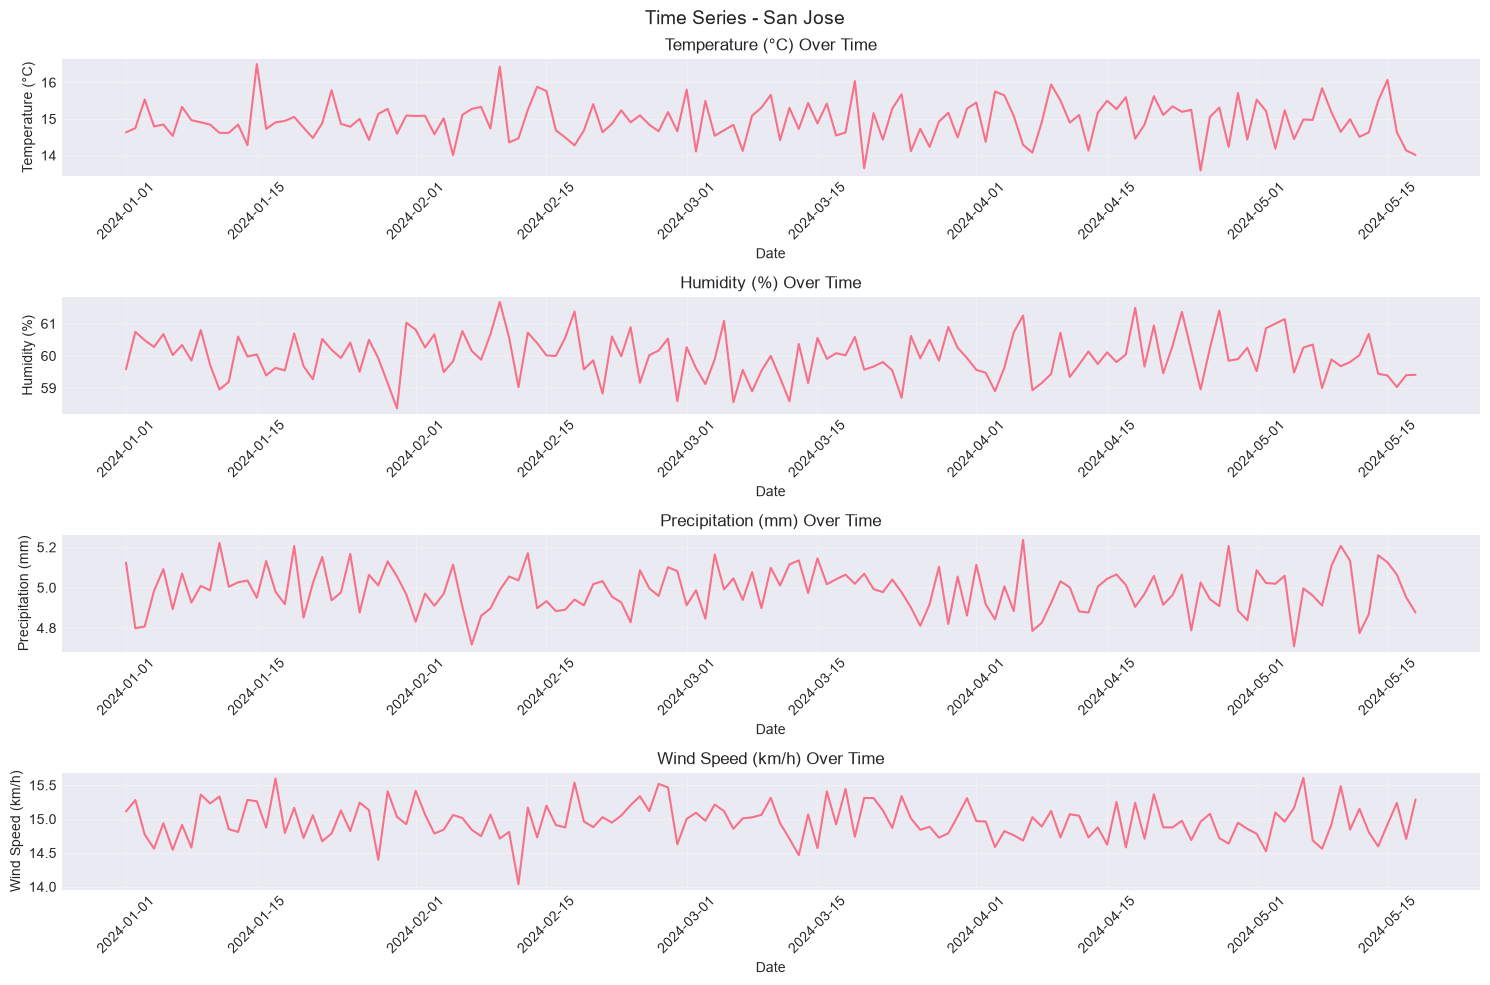


Plotting time series for New York...


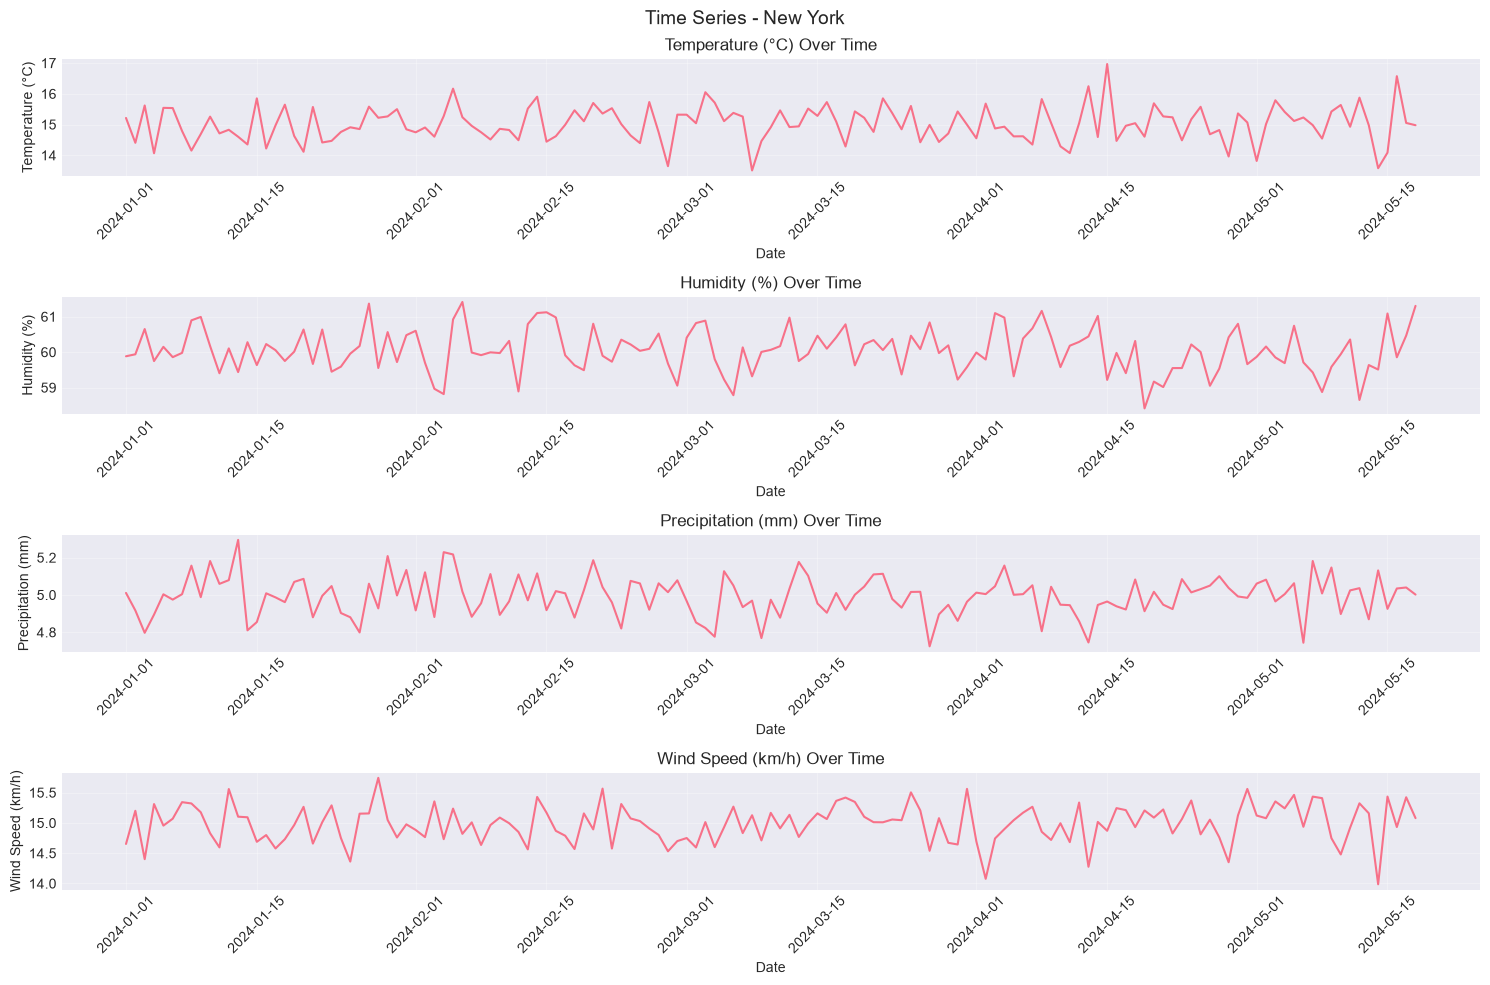


Plotting time series for Houston...


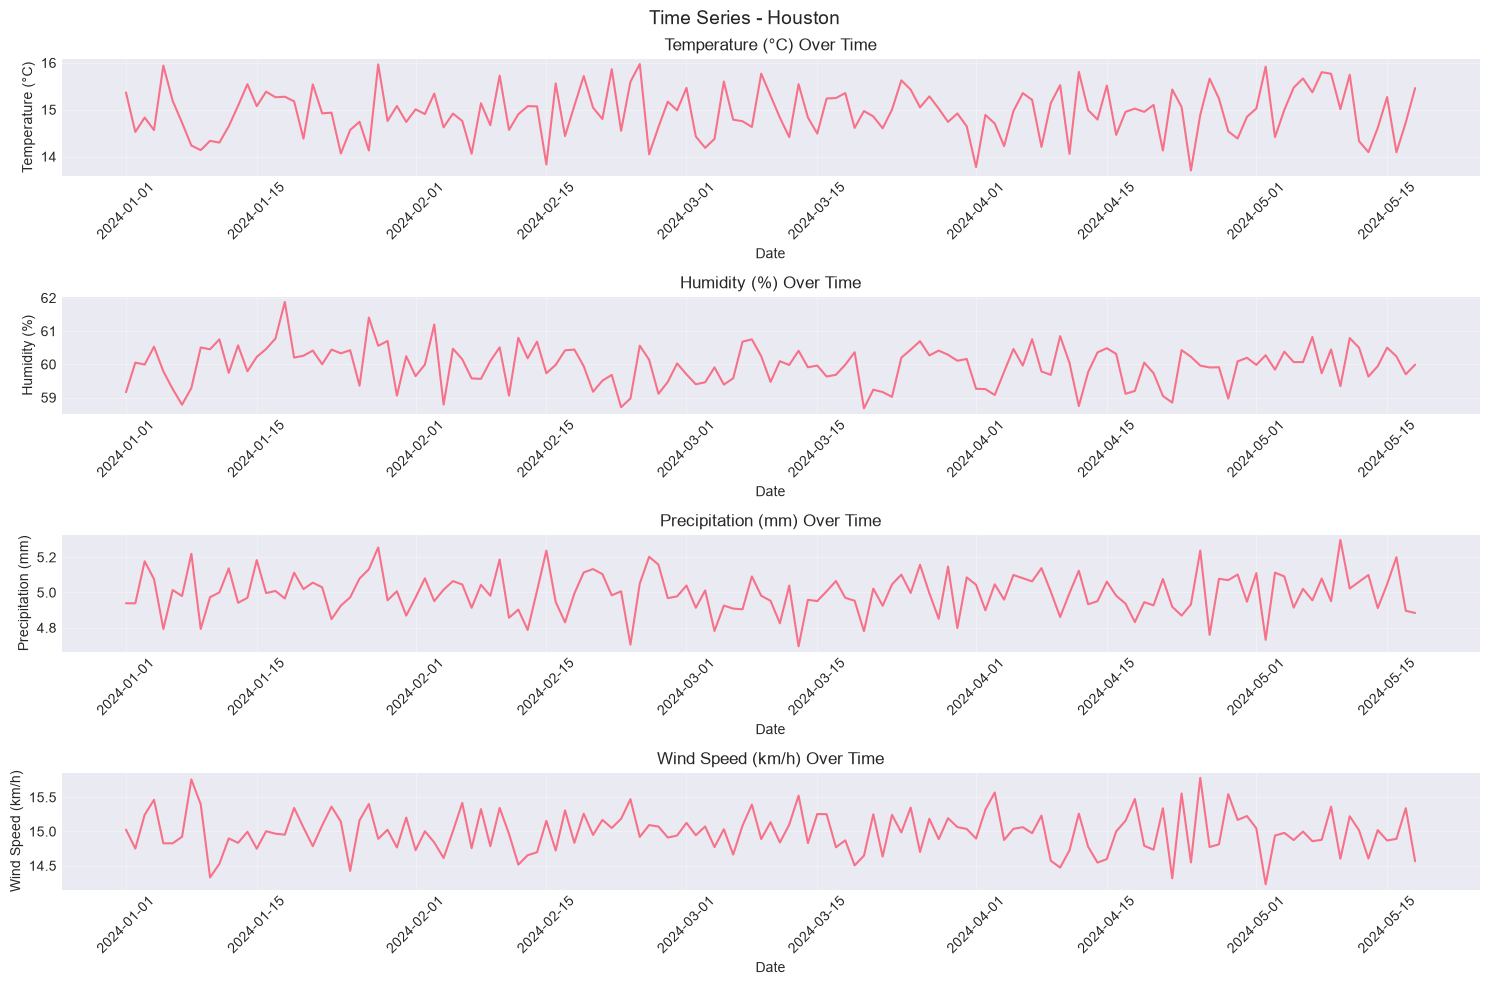


Plotting time series for Dallas...


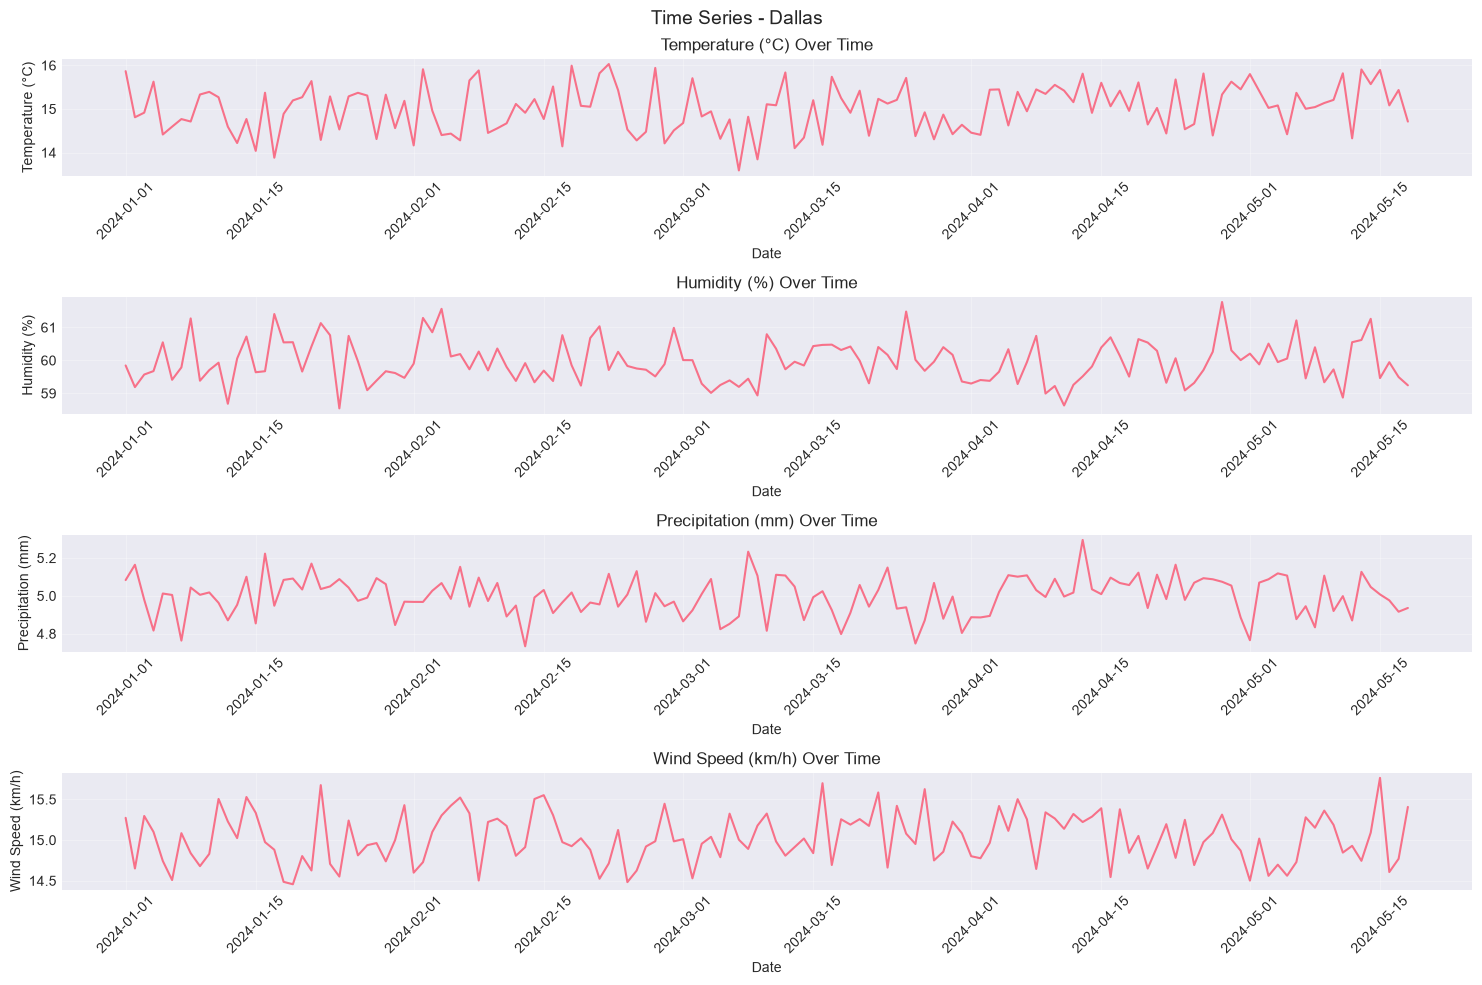


Plotting time series for Chicago...


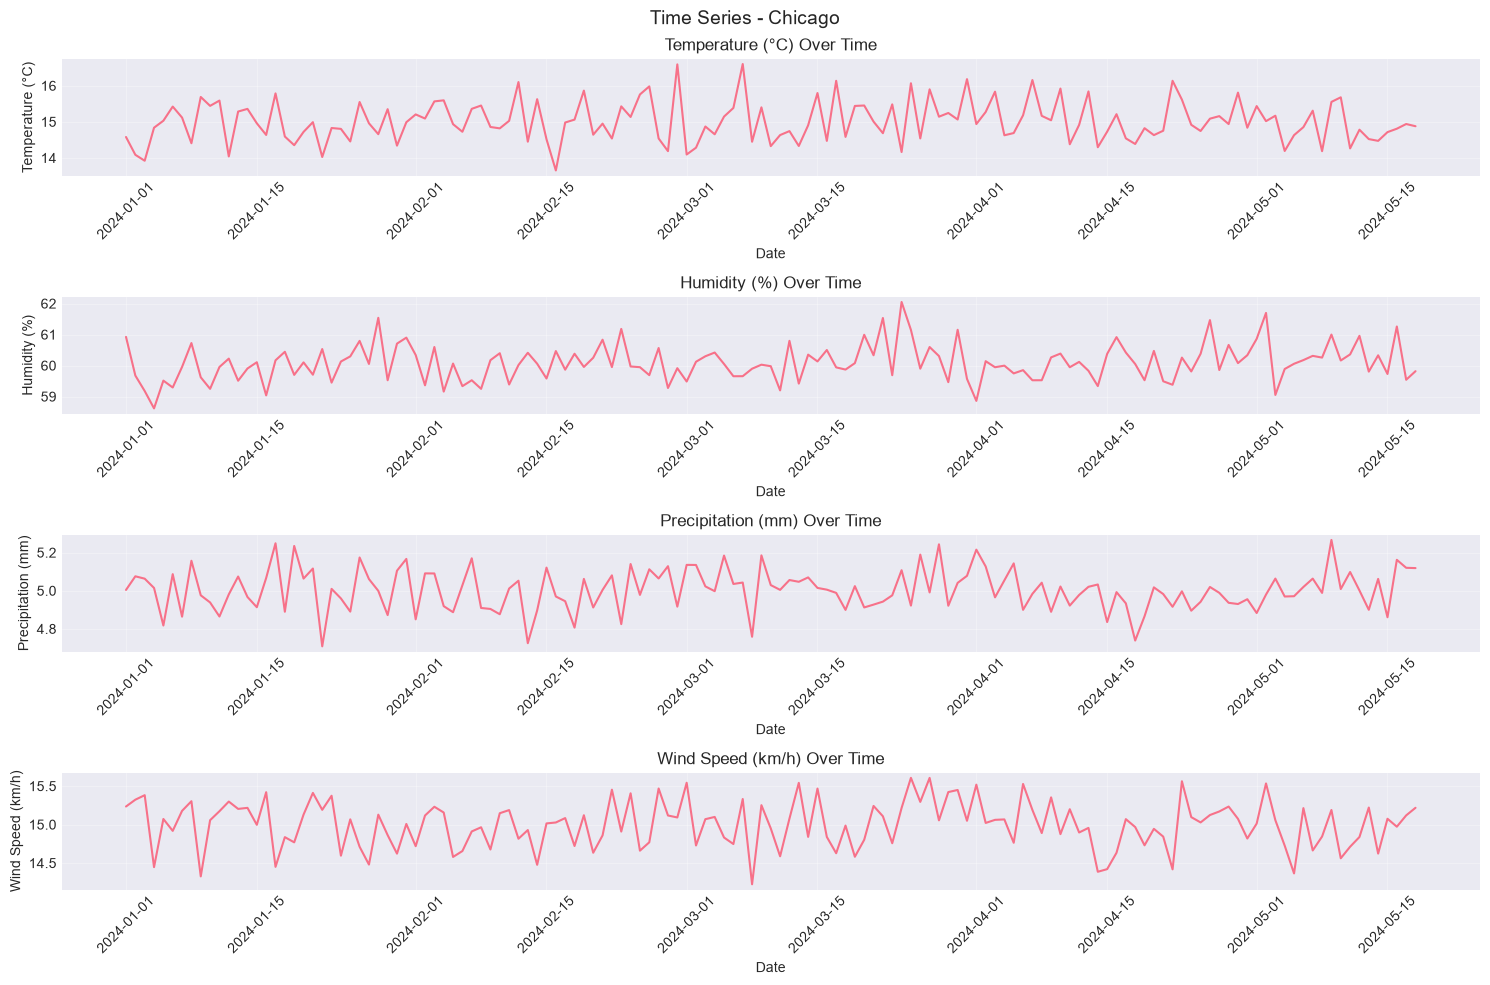


Plotting time series for Los Angeles...


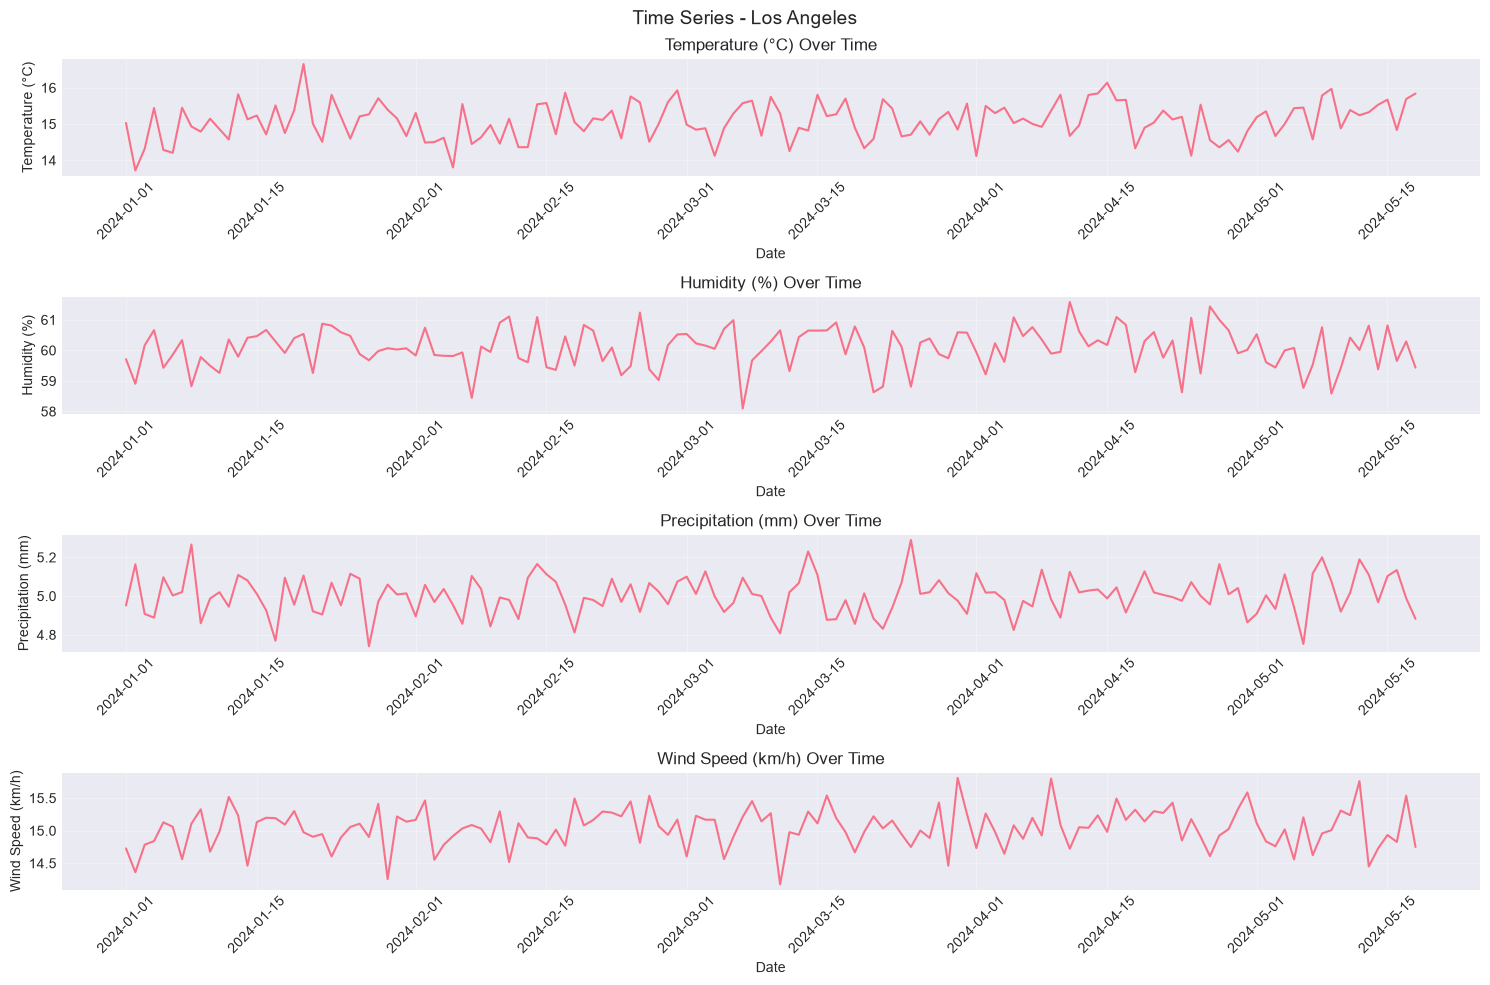


Plotting time series for Phoenix...


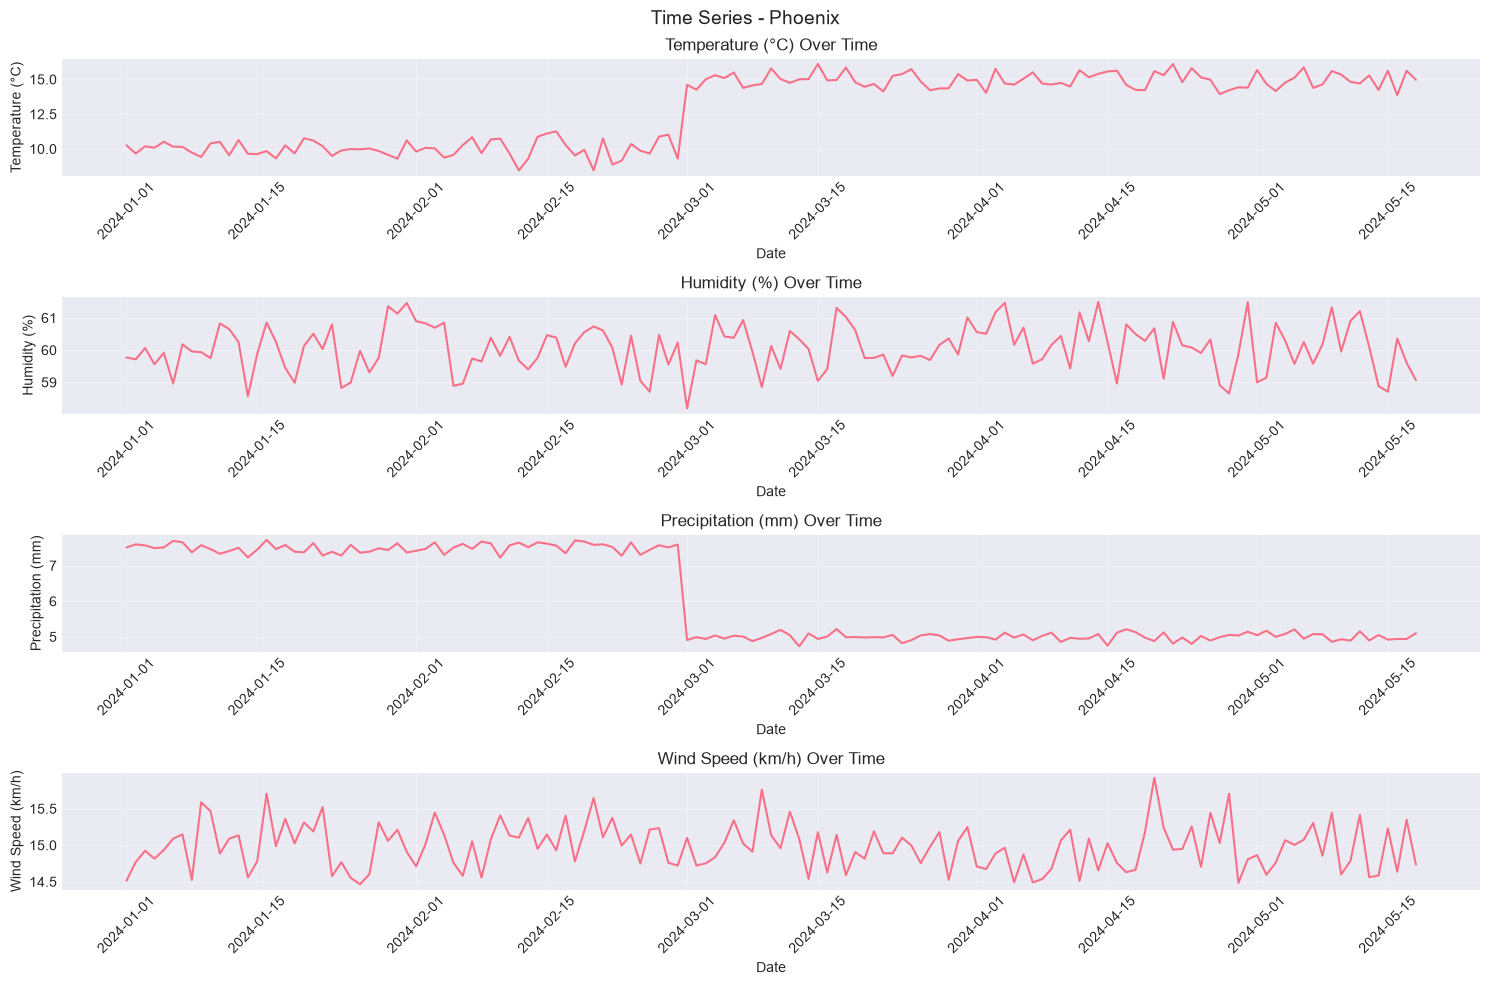

In [21]:
# Plotting time series for each location
for loc in locations:
    print(f"\nPlotting time series for {loc}...")
    plot_time_series(location=loc)